### Amazon Sentiment Data

In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import numpy as np
import lxmls.readers.sentiment_reader as srs
from lxmls.deep_learning.utils import AmazonData
corpus = srs.SentimentCorpus("books")
data = AmazonData(corpus=corpus)

### Exercise 2.2 Implement Backpropagation for an MLP in Numpy and train it
Instantiate the feed-forward model class and optimization parameters. This models follows the architecture described in Algorithm 7.

In [11]:
# Model
geometry = [corpus.nr_features, 20, 20, 2]
activation_functions = ['sigmoid', 'sigmoid', 'softmax']

# Optimization
learning_rate = 0.05
num_epochs = 10
batch_size = 30

In [12]:
import numpy as np
from lxmls.deep_learning.mlp import MLP
from lxmls.deep_learning.utils import index2onehot, logsumexp


class NumpyMLP(MLP):
    """
    Basic MLP with forward-pass and gradient computation in Numpy
    """

    def __init__(self, **config):

        # This will initialize
        # self.config
        # self.parameters
        MLP.__init__(self, **config)

    def predict(self, input=None):
        """
        Predict model outputs given input
        """
        log_class_probabilities, _ = self.log_forward(input)
        return np.argmax(np.exp(log_class_probabilities), axis=1)

    def update(self, input=None, output=None):
        """
        Update model parameters given batch of data
        """

        gradients = self.backpropagation(input, output)

        learning_rate = self.config['learning_rate']
        num_parameters = len(self.parameters)
        for m in np.arange(num_parameters):

            # Update weight
            self.parameters[m][0] -= learning_rate * gradients[m][0]

            # Update bias
            self.parameters[m][1] -= learning_rate * gradients[m][1]

    def log_forward(self, input):
        """Forward pass for sigmoid hidden layers and output softmax"""

        # Input
        tilde_z = input
        layer_inputs = []

        # Hidden layers
        num_hidden_layers = len(self.parameters) - 1
        for n in range(num_hidden_layers):

            # Store input to this layer (needed for backpropagation)
            layer_inputs.append(tilde_z)

            # Linear transformation
            weight, bias = self.parameters[n]
            z = np.dot(tilde_z, weight.T) + bias

            # Non-linear transformation (sigmoid)
            tilde_z = 1.0 / (1 + np.exp(-z))

        # Store input to this layer (needed for backpropagation)
        layer_inputs.append(tilde_z)

        # Output linear transformation
        weight, bias = self.parameters[num_hidden_layers]
        z = np.dot(tilde_z, weight.T) + bias

        # Softmax is computed in log-domain to prevent underflow/overflow
        log_tilde_z = z - logsumexp(z, axis=1, keepdims=True)

        return log_tilde_z, layer_inputs

    def cross_entropy_loss(self, input, output):
        """Cross entropy loss"""
        num_examples = input.shape[0]
        log_probability, _ = self.log_forward(input)
        return -log_probability[range(num_examples), output].mean()

    def backpropagation(self, input, output):
        """Gradients for sigmoid hidden layers and output softmax"""

        # Run forward and store activations for each layer
        log_prob_y, layer_inputs = self.log_forward(input)
        prob_y = np.exp(log_prob_y)
        

        num_examples, num_classes = prob_y.shape
        num_hidden_layers = len(self.parameters) - 1

        # For each layer in reverse store the backpropagated error, then compute
        # the gradients from the errors and the layer inputs
        errors = [None for _ in range(num_hidden_layers+1)]
    
        I = index2onehot(output, num_classes)  

        errors[-1] = I-prob_y
        for n in range(num_hidden_layers-1, -1, -1):
            weight, bias = self.parameters[n+1]
            errors[n] = errors[n+1]@weight
            errors[n] = errors[n]*layer_inputs[n+1]*(1-layer_inputs[n+1])

        
        gradients = [[None, None] for _ in range(num_hidden_layers+1)]
        for n in range(num_hidden_layers+1):
            gradients[n][0] = -(errors[n].T@layer_inputs[n])/num_examples
            gradients[n][1] = -np.sum(errors[n], axis=0, keepdims=True)/num_examples
        
        return gradients

model = NumpyMLP(
    geometry=geometry,
    activation_functions=activation_functions,
    learning_rate=learning_rate
)

#### Milestone 1:
Open the code for this model. This is located in 

    lxmls/deep_learning/numpy_models/mlp.py
    
Implement the method `backpropagation()` in the class `NumpyMLP` using Backpropagation recursion that we just saw.

As a first step focus on getting the gradients of each layer, one at a time. Use the code below to plot the loss values for the study weight and perturbed versions. 

In [13]:
from lxmls.deep_learning.mlp import get_mlp_parameter_handlers, get_mlp_loss_range

# Get functions to get and set values of a particular weight of the model
get_parameter, set_parameter = get_mlp_parameter_handlers(
    layer_index=1,
    is_bias=False,
    row=0, 
    column=0
)

# Get batch of data
batch = data.batches('train', batch_size=batch_size)[0]

# Get loss and weight value
current_loss = model.cross_entropy_loss(batch['input'], batch['output'])
current_weight = get_parameter(model.parameters)

# Get range of values of the weight and loss around current parameters values
weight_range, loss_range = get_mlp_loss_range(model, get_parameter, set_parameter, batch)

In [14]:
for p in model.parameters:
    w,b=p
    print(w.shape)

(20, 13989)
(20, 20)
(2, 20)


In [15]:
# Get the gradient value for that weight
gradients = model.backpropagation(batch['input'], batch['output'])
current_gradient = get_parameter(gradients)

Once you have implemented at least the gradient of the last layer. You can start checking if the values match

Now you can plot the values of the loss around a given parameters value versus the gradient. If you have implemented this correctly the gradient should be tangent to the loss at the current weight value, see Figure 3.5. Once you have completed the exercise, you should be able to plot also the gradients of the other layers. Take into account that the gradients for the first layer will only be non zero for the indices of words present in the batch. You can locate this using.

In [16]:
# Use this to know the non-zero values of the input (that have non-zero gradient)
batch['input'][0].nonzero()

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131]),)

Copy the following code for plotting

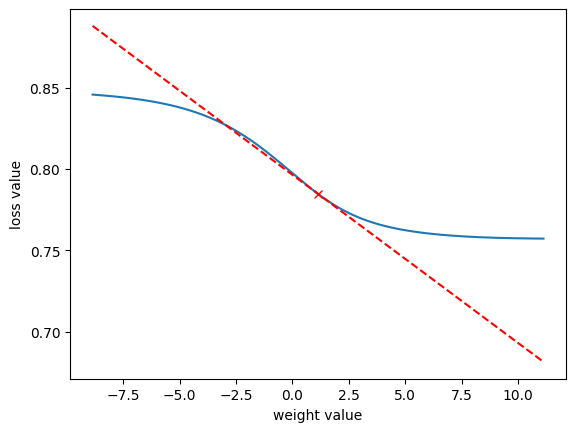

In [17]:
%matplotlib inline
import matplotlib.pyplot as plt
# Plot empirical
plt.plot(weight_range, loss_range)
plt.plot(current_weight, current_loss, 'xr')
plt.ylabel('loss value')
plt.xlabel('weight value')
# Plot real
h = plt.plot(
    weight_range,
    current_gradient*(weight_range - current_weight) + current_loss, 
    'r--'
)
plt.show()

#### Milestone 2:
After you have ensured that your Backpropagation algorithm is correct, you can train a model with the data we have.

In [18]:
# Get batch iterators for train and test
train_batches = data.batches('train', batch_size=batch_size)
test_set = data.batches('test', batch_size=None)[0]

# Epoch loop
for epoch in range(20):

    # Batch loop
    for batch in train_batches:
        model.update(input=batch['input'], output=batch['output'])

    # Prediction for this epoch
    hat_y = model.predict(input=test_set['input'])

    # Evaluation
    accuracy = 100*np.mean(hat_y == test_set['output'])

    # Inform user
    print("Epoch %d: accuracy %2.2f %%" % (epoch+1, accuracy))

Epoch 1: accuracy 61.75 %
Epoch 2: accuracy 70.50 %
Epoch 3: accuracy 73.00 %
Epoch 4: accuracy 74.75 %
Epoch 5: accuracy 75.75 %
Epoch 6: accuracy 77.00 %
Epoch 7: accuracy 77.25 %
Epoch 8: accuracy 78.00 %
Epoch 9: accuracy 79.25 %
Epoch 10: accuracy 80.25 %
Epoch 11: accuracy 79.50 %
Epoch 12: accuracy 80.00 %
Epoch 13: accuracy 80.00 %
Epoch 14: accuracy 80.25 %
Epoch 15: accuracy 80.00 %
Epoch 16: accuracy 80.25 %
Epoch 17: accuracy 80.00 %
Epoch 18: accuracy 80.25 %
Epoch 19: accuracy 79.75 %
Epoch 20: accuracy 80.25 %
